# AI-Powered Retail Business Analytics & Forecasting Platform

# Phase 5: Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the integrated retail dataset and identify important patterns, trends, relationships, and business insights.

EDA helps us understand:

- Sales performance
- Customer behavior
- Product performance
- Category trends
- Regional performance
- Order patterns
- Delivery performance
- Payment behavior
- Customer satisfaction

The insights obtained from this phase will guide feature engineering, machine learning, and business recommendations.

In [43]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go


import warnings
warnings.filterwarnings("ignore")


pd.set_option("display.max_columns",None)
pd.set_option("display.float_format","{:.2f}".format)

In [44]:
df = pd.read_csv(
    "C:/Users/rames/notebook/DS-1/data/processed/master_retail_dataset.csv"
)

In [45]:
df.shape

(114100, 39)

In [46]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,seller_zip_code_prefix,seller_city,seller_state,payment_value,payment_installments,payment_type,review_score,delivery_days,delivery_delay_days,total_order_value,purchase_year,purchase_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,9350.00,maua,SP,38.71,1.00,credit_card,4,8.00,-8.00,38.71,2017,10
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,barreiras,BA,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,31570.00,belo horizonte,SP,141.46,1.00,boleto,4,13.00,-6.00,141.46,2018,7
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,14840.00,guariba,SP,179.12,3.00,credit_card,5,9.00,-18.00,179.12,2018,8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,7c142cf63193a1473d2e66489a9ae977,59296,sao goncalo do amarante,RN,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,31842.00,belo horizonte,MG,72.20,1.00,credit_card,5,13.00,-13.00,72.20,2017,11
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,8752.00,mogi das cruzes,SP,28.62,1.00,credit_card,5,2.00,-10.00,28.62,2018,2


In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114100 entries, 0 to 114099
Data columns (total 39 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       114100 non-null  object 
 1   customer_id                    114100 non-null  object 
 2   order_status                   114100 non-null  object 
 3   order_purchase_timestamp       114100 non-null  object 
 4   order_approved_at              114100 non-null  object 
 5   order_delivered_carrier_date   114100 non-null  object 
 6   order_delivered_customer_date  114100 non-null  object 
 7   order_estimated_delivery_date  114100 non-null  object 
 8   customer_unique_id             114100 non-null  object 
 9   customer_zip_code_prefix       114100 non-null  int64  
 10  customer_city                  114100 non-null  object 
 11  customer_state                 114100 non-null  object 
 12  order_item_id                 

In [48]:
df.describe()

,customer_zip_code_prefix,order_item_id,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,seller_zip_code_prefix,payment_value,payment_installments,review_score,delivery_days,delivery_delay_days,total_order_value,purchase_year,purchase_month
count,114100.00,113322.00,114100.00,114100.00,113322.00,113322.00,113322.00,113322.00,113322.00,113322.00,113322.00,113322.00,114100.00,114100.00,114100.00,110847.00,110847.00,114100.00,114100.00,114100.00
mean,35105.75,1.20,119.66,19.84,48.81,784.15,2.19,2091.75,30.16,16.58,23.00,24441.49,180.38,3.02,4.00,12.01,-12.04,139.50,2017.54,6.03
std,29868.32,0.71,182.92,15.81,9.96,647.49,1.71,3749.53,16.15,13.44,11.71,27597.07,273.06,2.81,1.41,9.45,10.16,190.06,0.51,3.24
min,1003.00,1.00,0.00,0.00,5.00,4.00,1.00,0.00,7.00,2.00,6.00,1001.00,0.00,0.00,1.00,0.00,-147.00,0.00,2016.00,1.00
25%,11250.00,1.00,39.90,12.95,43.00,348.00,1.00,300.00,18.00,8.00,15.00,6429.00,65.63,1.00,3.00,6.00,-17.00,54.70,2017.00,3.00
50%,24320.00,1.00,74.00,16.21,51.00,595.00,1.00,700.00,25.00,13.00,20.00,13568.00,114.33,2.00,5.00,10.00,-13.00,91.41,2018.00,6.00
75%,59022.00,1.00,133.00,21.14,57.00,979.00,3.00,1800.00,38.00,20.00,30.00,27930.00,195.39,4.00,5.00,15.00,-7.00,157.30,2018.00,8.00
max,99990.00,21.00,6735.00,409.68,76.00,3992.00,20.00,40425.00,105.00,105.00,118.00,99730.00,13664.08,24.00,5.00,209.00,188.00,6929.31,2018.00,12.00


In [49]:
missing = (
    df.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
)

missing[missing>0]

delivery_days                 3253
delivery_delay_days           3253
order_item_id                  778
seller_id                      778
product_id                     778
product_description_lenght     778
product_name_lenght            778
seller_zip_code_prefix         778
product_width_cm               778
seller_city                    778
seller_state                   778
product_height_cm              778
product_length_cm              778
product_category_name          778
product_photos_qty             778
product_weight_g               778
shipping_limit_date            778
dtype: int64

In [50]:
missing_percent = (
    df.isnull().mean() * 100
).round(2)

missing_report = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

missing_report = missing_report[
    missing_report["Missing Count"] > 0
]

display(missing_report)

,Missing Count,Missing %
delivery_days,3253,2.85
delivery_delay_days,3253,2.85
order_item_id,778,0.68
product_category_name,778,0.68
product_description_lenght,778,0.68
product_height_cm,778,0.68
product_id,778,0.68
product_length_cm,778,0.68
product_name_lenght,778,0.68
product_photos_qty,778,0.68


In [51]:
required_columns = [
    "order_purchase_timestamp",
    "total_order_value",
    "product_category_name_english",
    "customer_state",
    "payment_type",
    "review_score"
]

missing_columns = [
    col for col in required_columns
    if col not in df.columns
]

if missing_columns:
    print("Missing columns:", missing_columns)
else:
    print("All required columns are present.")

All required columns are present.


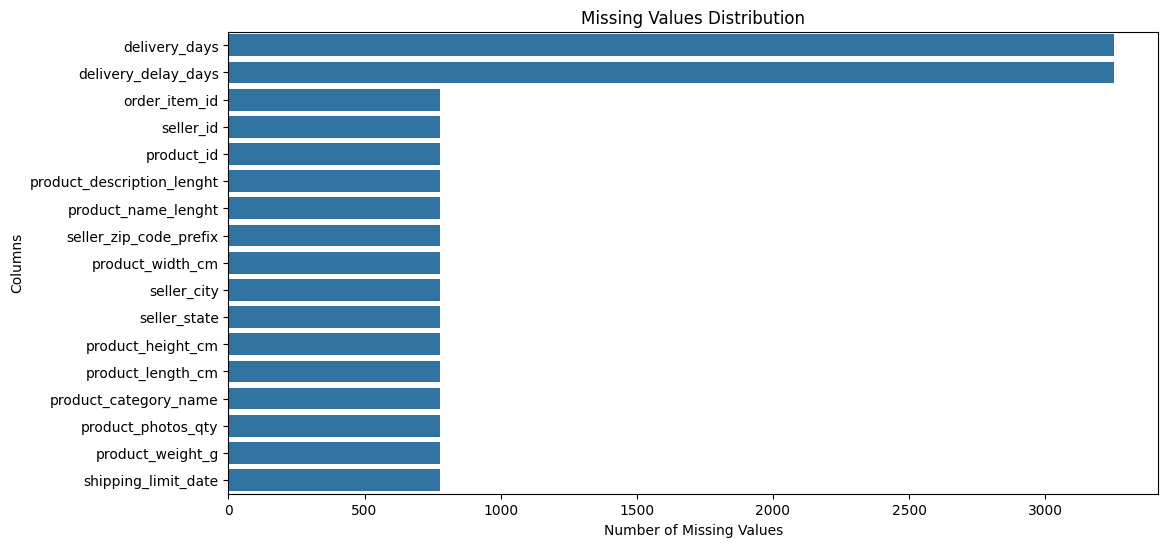

In [52]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=missing[missing>0].values,
    y=missing[missing>0].index
)

plt.title(
    "Missing Values Distribution"
)

plt.xlabel(
    "Number of Missing Values"
)

plt.ylabel(
    "Columns"
)

plt.show()

Observation:

Some columns contain missing values because certain information was not available in the original transaction system.

Examples:

- Review comments may be missing because customers did not provide feedback.
- Delivery dates may be missing for cancelled orders.

These missing values will be handled according to business requirements.

In [53]:
order_status = (
    df["order_status"]
    .value_counts()
)


order_status

order_status
delivered      110848
shipped          1197
canceled          711
unavailable       612
invoiced          366
processing        358
created             5
approved            3
Name: count, dtype: int64

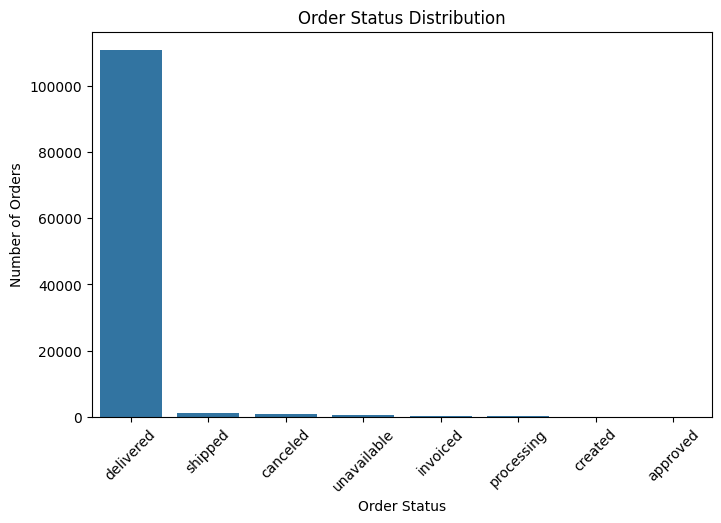

In [54]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=order_status.index,
    y=order_status.values
)

plt.title(
    "Order Status Distribution"
)

plt.xlabel(
    "Order Status"
)

plt.ylabel(
    "Number of Orders"
)

plt.xticks(rotation=45)

plt.show()

Insights:

- Majority of orders are completed successfully.
- Cancelled orders represent a small percentage.
- Order status analysis helps understand operational efficiency.

In [55]:
total_sales = df["total_order_value"].sum()

total_sales

np.float64(15917317.929999998)

In [56]:
average_order_value = (
    df["total_order_value"]
    .mean()
)

average_order_value

np.float64(139.5032246275197)

In [57]:
total_orders = (
    df["order_id"]
    .nunique()
)

total_orders

99441

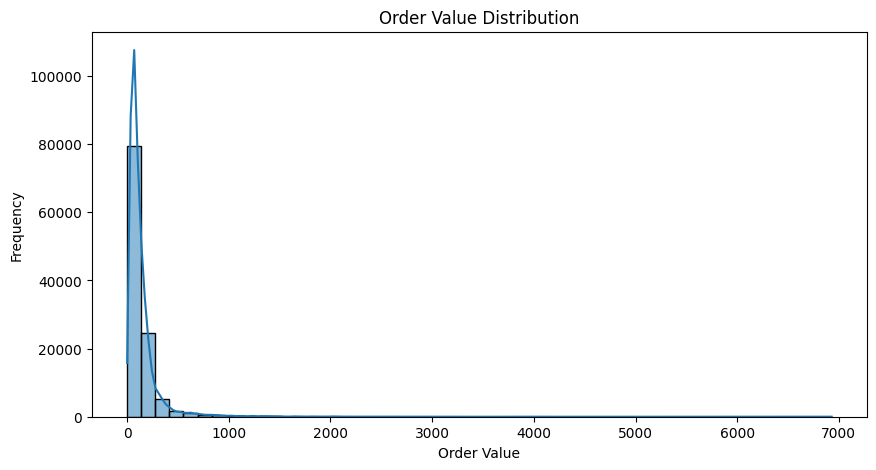

In [58]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["total_order_value"],
    bins=50,
    kde=True
)

plt.title(
    "Order Value Distribution"
)

plt.xlabel(
    "Order Value"
)

plt.ylabel(
    "Frequency"
)

plt.show()

In [59]:
df["order_purchase_timestamp"] = pd.to_datetime(
    df["order_purchase_timestamp"],
    errors="coerce"
)

In [60]:
print(df["order_purchase_timestamp"].isnull().sum())

0


In [61]:
sales_df = df.dropna(
    subset=[
        "order_purchase_timestamp",
        "total_order_value"
    ]
)

In [62]:
category_df = df[
    df["product_category_name_english"] != "Unknown"
].copy()

In [63]:
monthly_sales = (

df
.groupby(
df["order_purchase_timestamp"]
.dt.to_period("M")
)["total_order_value"]
.sum()

.reset_index()

)


monthly_sales["order_purchase_timestamp"] = (
monthly_sales["order_purchase_timestamp"]
.astype(str)
)

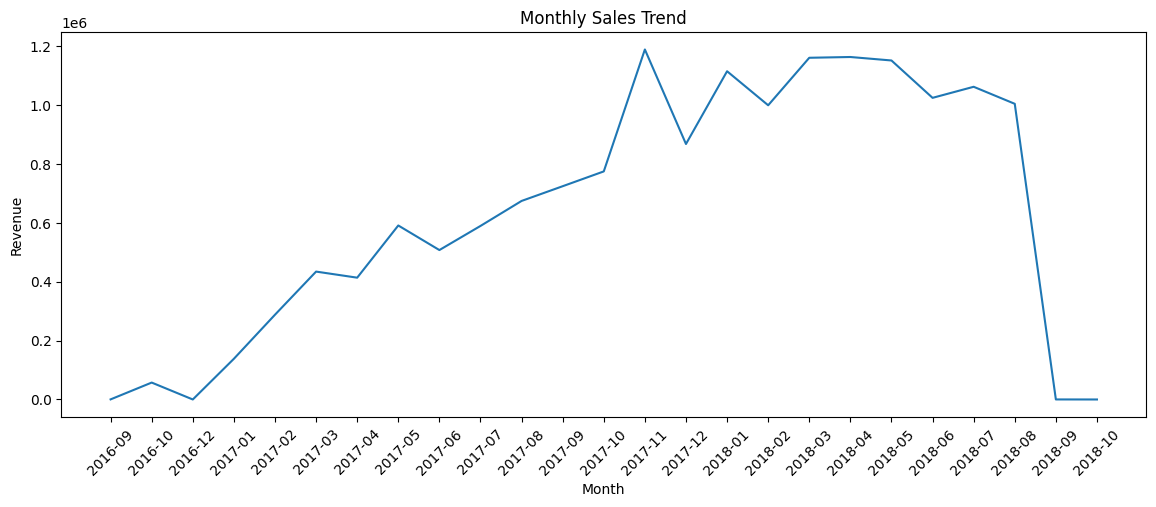

In [64]:
plt.figure(figsize=(14,5))

sns.lineplot(
data=monthly_sales,
x="order_purchase_timestamp",
y="total_order_value"
)

plt.xticks(rotation=45)

plt.title(
"Monthly Sales Trend"
)

plt.xlabel(
"Month"
)

plt.ylabel(
"Revenue"
)

plt.show()

Insights:

- Sales show seasonal variation.
- Certain months generate higher revenue.
- These patterns can be used for sales forecasting.

In [65]:
unique_customers = (
df["customer_unique_id"]
.nunique()
)

unique_customers

96096

In [66]:
customer_state = (
df["customer_state"]
.value_counts()
.head(10)
)


customer_state

customer_state
SP    48096
RJ    14758
MG    13301
RS     6322
PR     5811
SC     4216
BA     3842
DF     2448
GO     2366
ES     2277
Name: count, dtype: int64

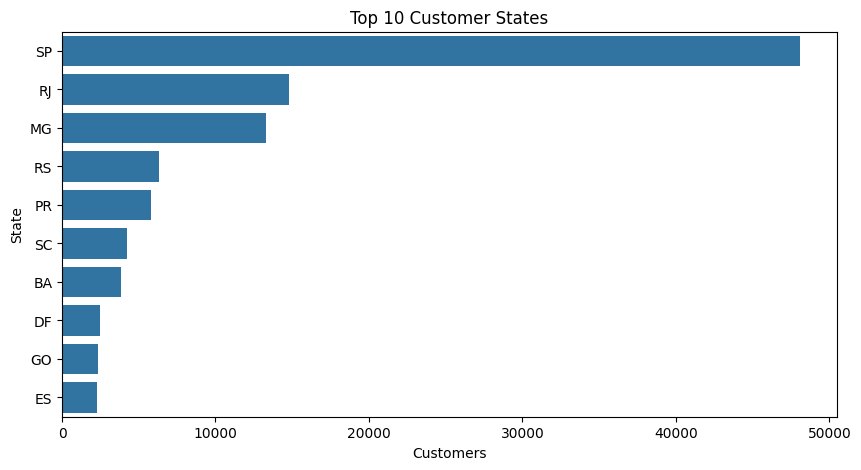

In [67]:
plt.figure(figsize=(10,5))


sns.barplot(
x=customer_state.values,
y=customer_state.index
)


plt.title(
"Top 10 Customer States"
)


plt.xlabel(
"Customers"
)


plt.ylabel(
"State"
)


plt.show()

In [68]:
category_sales = (

df
.groupby(
"product_category_name_english"
)
["total_order_value"]
.sum()
.sort_values(
ascending=False
)
.head(10)

)


category_sales

product_category_name_english
health_beauty           1446734.79
watches_gifts           1306761.40
bed_bath_table          1258396.24
sports_leisure          1163377.02
computers_accessories   1068164.08
furniture_decor          911103.13
housewares               781170.03
cool_stuff               721492.90
auto                     687374.19
garden_tools             585646.54
Name: total_order_value, dtype: float64

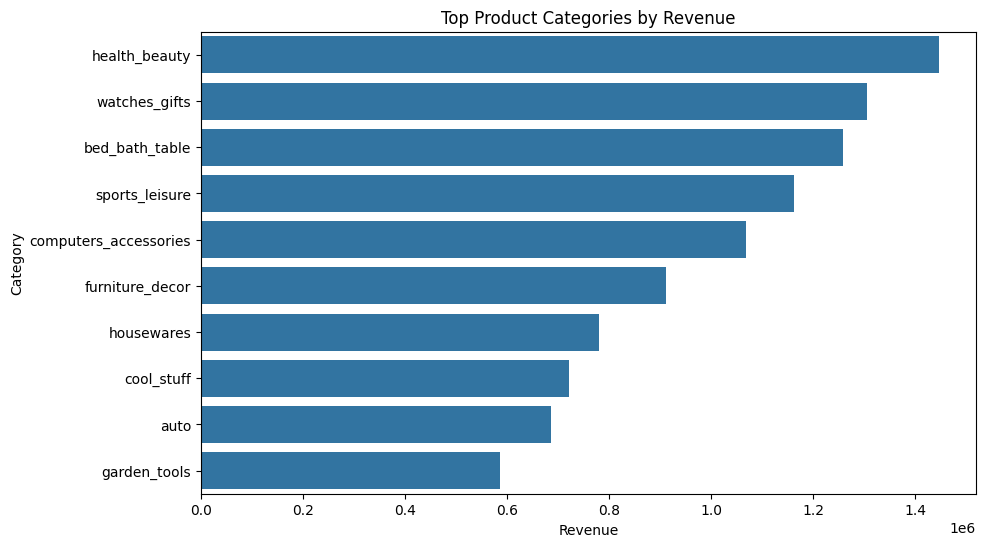

In [69]:
plt.figure(figsize=(10,6))


sns.barplot(
x=category_sales.values,
y=category_sales.index
)


plt.title(
"Top Product Categories by Revenue"
)


plt.xlabel(
"Revenue"
)


plt.ylabel(
"Category"
)


plt.show()

In [70]:
top_products = (

df
.groupby(
"product_id"
)["price"]
.sum()
.sort_values(
ascending=False
)
.head(10)

)


top_products

product_id
bb50f2e236e5eea0100680137654686c   64210.00
6cdd53843498f92890544667809f1595   54730.20
d6160fb7873f184099d9bc95e30376af   48899.34
d1c427060a0f73f6b889a5c7c61f2ac4   47214.51
99a4788cb24856965c36a24e339b6058   43292.26
3dd2a17168ec895c781a9191c1e95ad7   41082.60
25c38557cf793876c5abdd5931f922db   38907.32
5f504b3a1c75b73d6151be81eb05bdc9   37733.90
53b36df67ebb7c41585e8d54d6772e08   37683.42
aca2eb7d00ea1a7b8ebd4e68314663af   37608.90
Name: price, dtype: float64

In [71]:
payment_types = (

df["payment_type"]
.value_counts()

)

payment_types

payment_type
credit_card    86191
boleto         23190
voucher         3009
debit_card      1704
not_defined        3
Unknown            3
Name: count, dtype: int64

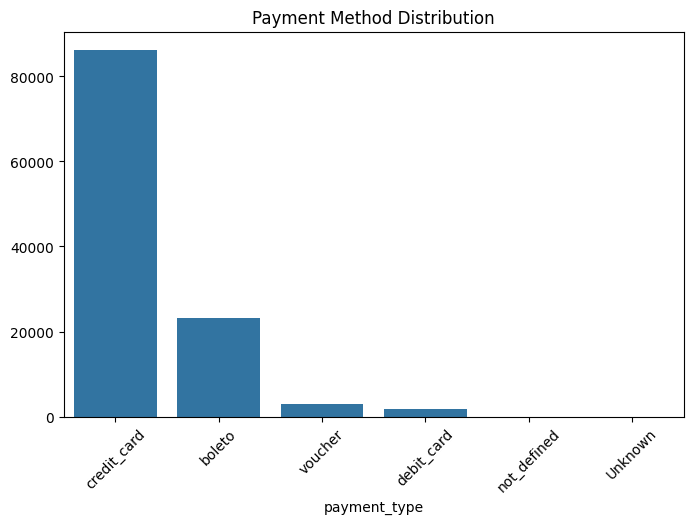

In [72]:
plt.figure(figsize=(8,5))


sns.barplot(
x=payment_types.index,
y=payment_types.values
)


plt.title(
"Payment Method Distribution"
)


plt.xticks(rotation=45)

plt.show()

In [73]:
review_scores = (

df["review_score"]
.value_counts()
.sort_index()

)


review_scores

review_score
1    15342
2     4048
3     9597
4    21415
5    63698
Name: count, dtype: int64

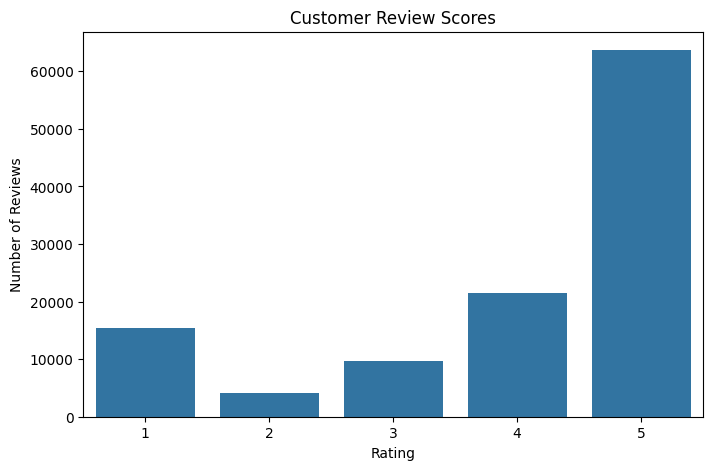

In [74]:
plt.figure(figsize=(8,5))

sns.barplot(
x=review_scores.index,
y=review_scores.values
)

plt.title(
"Customer Review Scores"
)

plt.xlabel(
"Rating"
)

plt.ylabel(
"Number of Reviews"
)

plt.show()

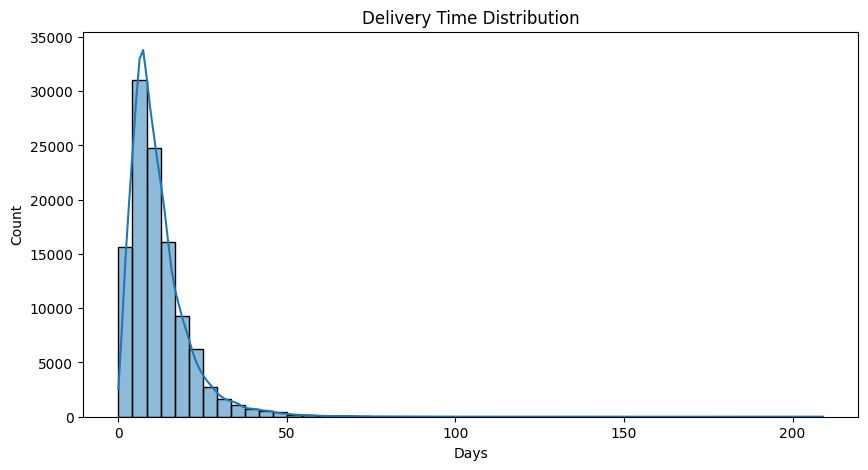

In [75]:
plt.figure(figsize=(10,5))

sns.histplot(
df["delivery_days"],
bins=50,
kde=True
)

plt.title(
"Delivery Time Distribution"
)

plt.xlabel(
"Days"
)

plt.show()

In [76]:
numeric_columns = [

"price",
"freight_value",
"payment_value",
"review_score",
"product_weight_g",
"delivery_days"

]


corr = df[numeric_columns].corr()

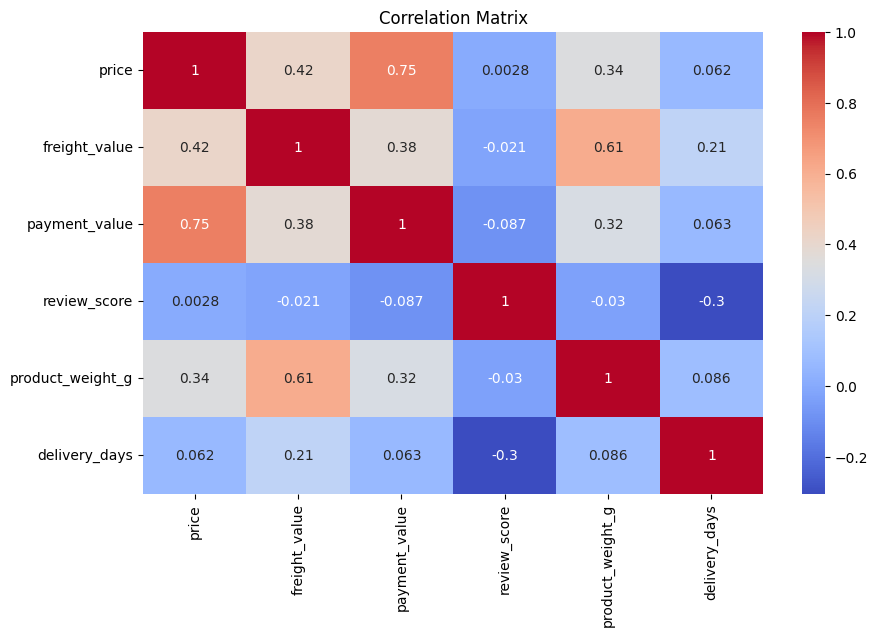

In [77]:
plt.figure(figsize=(10,6))

sns.heatmap(
corr,
annot=True,
cmap="coolwarm"
)


plt.title(
"Correlation Matrix"
)


plt.show()

# monthly_sales.to_csv(
    "../reports/eda/monthly_sales.csv",
    index=False
)EDA Summary

## Sales

- Revenue varies across different months.
- Seasonal patterns are visible.

## Customers

- A few states contribute a large portion of customers.
- Customer distribution is not uniform.

## Products

- Some categories dominate revenue.
- Product performance varies significantly.

## Payments

- Certain payment methods are preferred by customers.

## Reviews

- Customer satisfaction can be analyzed using review scores.

## Delivery

- Delivery time affects customer experience.

In [78]:
monthly_sales.to_csv(
    "../reports/eda/monthly_sales.csv",
    index=False
)

category_sales.to_csv(
    "../reports/eda/category_sales.csv",
    index=False
)

# Conclusion

Exploratory Data Analysis helped us understand the behavior of the retail business dataset.

Major areas analyzed:

- Sales trends
- Customer distribution
- Product performance
- Category performance
- Payment behavior
- Customer satisfaction
- Delivery performance

The insights obtained from EDA will be used in the next phase:
Feature Engineering.

In the next notebook, we will create new business features required for analytics and machine learning models.